# US Prevalence of Disease Categories

| Disease Group | US Prevalence | Source & Link |
| :--- | :--- | :--- |
| **Cardiovascular** | **48.6%** | [AHA Heart Disease & Stroke Statistics 2023](https://www.ahajournals.org/doi/10.1161/CIR.0000000000001123)<br>*(Comprises all CVD: Hypertension, CHD, Heart Failure, Stroke)* |
| **Oral & Dental Health** | **42.0%** | [CDC Periodontal Disease Facts](https://www.cdc.gov/oral-health/about/gum-periodontal-disease.html)<br>*(Adults ≥30 with some form of periodontal disease)* |
| **Respiratory Diseases** | **39.1%** | [Pulmonary Therapy (2022)](https://pmc.ncbi.nlm.nih.gov/articles/PMC9458821/#:~:text=Among%20adults%20%E2%89%A5%2018%20years,any%20other%20comorbidity%20except%20cancer)<br>*(Adults with respiratory impairment)* |
| **Dementia & Mental Health** | **23.1%** | [NIMH Mental Illness Statistics](https://www.nimh.nih.gov/health/statistics/mental-illness)<br>*(Prevalence of "Any Mental Illness" in US Adults)* |
| **Digestive & Liver** | **21.0%** | [NIDDK Digestive Diseases Statistics](https://www.niddk.nih.gov/health-information/health-statistics/digestive-diseases)<br>*(Est. 60–70 million affected by all digestive diseases)* |
| **Arthritis & Bone** | **18.9%** | [CDC NCHS Data Brief No. 497 (2024)](https://www.cdc.gov/nchs/products/databriefs/db497.htm)<br>*(Diagnosed arthritis in adults ≥18)* |
| **Kidney Disease** | **14.0%** | [CDC CKD Surveillance System](https://www.cdc.gov/kidney-disease/php/data-research/index.html)<br>*(Estimated prevalence of CKD Stages 1–4)* |
| **Diabetes** | **11.3%** | [CDC NCHS Data Brief No. 516 (2024)](https://www.cdc.gov/nchs/products/databriefs/db516.htm)<br>*(Diagnosed diabetes; total prevalence is higher)* |
| **Anemia** | **9.3%** | [CDC NCHS Data Brief No. 519 (2024)](https://www.cdc.gov/nchs/products/databriefs/db519.htm)<br>*(Prevalence of anemia in population aged ≥2)* |
| **Cancer** | **10.3%** | [CDC Cancer Data and Statistics](https://www.cdc.gov/nchs/fastats/cancer.htm)<br>*(Cancer survivors / prevalence)* |
| **Sepsis** | **0.5%** | [CDC Sepsis Clinical Information](https://www.cdc.gov/sepsis/about/index.html)<br>*(Calculated from 1.7M annual cases / US Population in 2017)* |

In [1]:
import pandas as pd

data = pd.read_pickle('/Users/kumars33/Desktop/Diabetes_LLM_annotation/GLP_AMIA/glp_linked_diagnosis_data.pkl')

In [3]:
len(data.keys())

140

Prevalence Comparison Table:


,Condition,US_Pop_Rate,Dataset_Rate
0,Cardiovascular,48.6,58.57
1,Oral & Dental Health,42.0,5.71
2,Respiratory Diseases,39.1,30.71
3,Dementia & Mental Health,23.1,17.14
4,Digestive & Liver,21.0,35.00
5,Arthritis & Bone,18.9,15.00
6,Kidney Disease,14.0,45.71
7,Diabetes,11.3,87.86
8,Cancer,10.3,15.00
9,Anemia,9.3,5.00


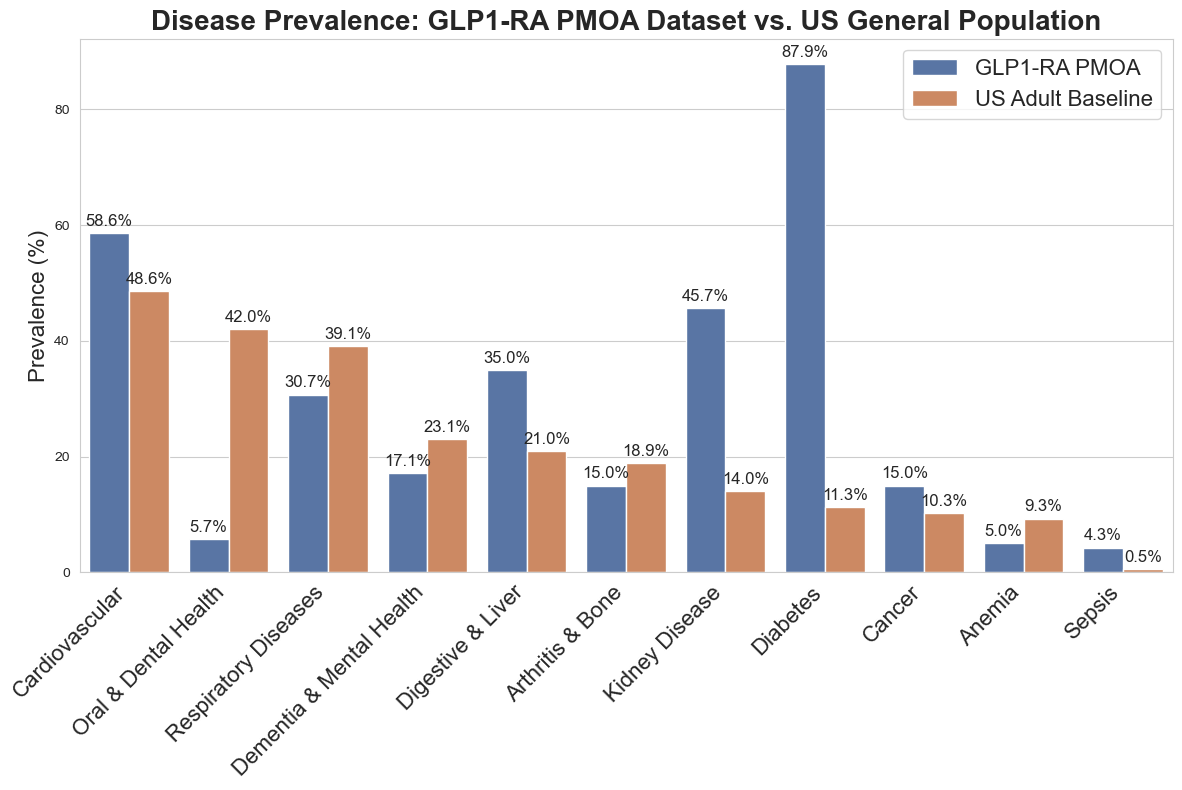

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
# data = pd.read_pickle('full_linked_diagnosis_data.pkl')

# 2. Extract ALL unique canonical names
all_unique_names = set()
for pmc_id, diagnoses in data.items():
    for raw_diag, candidates in diagnoses.items():
        if candidates:
            for cand in candidates:
                all_unique_names.add(cand['name'])

# 3. New Group Mapping Logic
def assign_disease_groups(name):
    name_lower = name.lower()
    groups = []
    
    # --- 1. Anemia (Expanded) ---
    # Includes specific types (sickle cell, thalassemia) and causes (B12, folate)
    if any(x in name_lower for x in [
        'anemia', 'anaemia', 'hemoglobin', 'haemoglobin', 'iron deficiency', 'iron', 
        'ferritin', 'thalassemia', 'sickle cell', 'sideroblastic', 'spherocytosis', 
        'pernicious', 'aplastic', 'hemolytic', 'cytopenia', 'pancytopenia', 
        'myelodysplastic', 'low rbc', 'erythroblastopenia'
    ]):
        groups.append('Anemia')

    # --- 2. Arthritis and Bone (Expanded) ---
    # Includes specific autoimmune arthritis, spinal conditions, and bone density issues
    if any(x in name_lower for x in [
        'arthritis', 'osteoarth', 'rheumatoid', 'gout', 'ankylosing', 'spondylitis', 
        'spondylosis', 'spondyloarthropathy', 'degenerative joint', 'arthropathy',
        'osteoporosis', 'osteopenia', 'bone density', 'fracture', 'bone loss', 'bone disease',
        'fibromyalgia', 'lupus', 'sle', 'connective tissue disease', 'polymyalgia',
        'scoliosis', 'kyphosis', 'lordosis', 'osteomyelitis', 'paget', 'rickets', 
        'osteomalacia', 'avascular necrosis', 'synovitis', 'bursitis', 'tendonitis'
    ]):
        groups.append('Arthritis & Bone')

    # --- 3. Cancer (Expanded) ---
    # Includes suffixes for tumor types, specific cancers, and therapy terms
    if any(x in name_lower for x in [
        'cancer', 'neoplasm', 'tumor', 'tumour', 'malignan', 'carcinoma', 'sarcoma', 
        'lymphoma', 'leukemia', 'leukaemia', 'myeloma', 'metastasis', 'metastatic', 
        'glioma', 'blastoma', 'melanoma', 'adenoca', 'plasmacytoma', 'cystadenoma', 
        'neurofibroma', 'oncolog', 'chemotherapy', 'radiation therapy', 'hodgkin', 
        'wilms', 'kaposi', 'seminoma', 'teratoma', 'mesothelioma', 'myeloproliferative'
    ]):
        groups.append('Cancer')

    # --- 4. Cardiovascular (Expanded) ---
    # Includes vascular issues, specific heart defects, and clotting events
    stroke_terms = [
        'stroke', 'cerebrovascular', 'cva', 'brain attack', 'transient ischemic', 'tia', 
        'hemorrhage', 'intracranial', 'cerebral aneurysm', 'subarachnoid', 'infarct'
    ]
    cholesterol_terms = [
        'lipid', 'cholesterol', 'hypercholes', 'dyslipidemia', 'triglyceride', 'lipoprotein', 
        'hyperlipidemia'
    ]
    heart_terms = [
        'coronary', 'heart disease', 'myocardial', 'heart failure', 'chf', 'atrial fib', 
        'afib', 'infarction', 'angina', 'ischemic', 'ischemia', 'valve', 'arrhythmia', 
        'ventricular', 'cardiomyopathy', 'tachycardia', 'bradycardia', 'fibrillation', 
        'stenosis', 'regurgitation', 'pericarditis', 'endocarditis', 'aneurysm', 
        'cardiovascular', 'cardiac', 'aortic', 'mitral', 'tricuspid', 'vascular', 
        'peripheral artery', 'pad', 'arteriosclerosis', 'atherosclerosis', 'thrombosis', 
        'embolism', 'dvt', 'phlebitis', 'claudication', 'hypertension', 'hypertensive', 
        'high blood pressure', 'pre-eclampsia', 'eclampsia', 'hellp syndrome', 'hypotension', 
        'shock', 'wolff-parkinson-white', 'qt interval'
    ]
    
    if any(x in name_lower for x in stroke_terms + cholesterol_terms + heart_terms):
        groups.append('Cardiovascular')

    # --- 5. Dementia and Mental Health (Expanded) ---
    # Includes developmental disorders, substance abuse, and specific psych conditions
    if any(x in name_lower for x in [
        'dementia', 'alzheimer', 'cognitive', 'delirium', 'amnesia', 'memory loss',
        'adhd', 'attention deficit', 'hyperactivity', 'autism', 'asperger', 
        'depression', 'depress', 'mood disorder', 'dysthymia', 'bipolar', 'mania', 
        'suicid', 'psychosis', 'psychotic', 'schizo', 'hallucination', 'delusion',
        'affective disorder', 'anhedonia', 'anxiety', 'panic', 'phobia', 'stress', 
        'obsess', 'compuls', 'ocd', 'ptsd', 'trauma', 'adjustment disorder',
        'mental', 'psychiatric', 'behavioral', 'emotional', 'insomnia', 
        'eating disorder', 'anorexia', 'bulimia', 'substance', 'dependence', 
        'alcoholism', 'withdrawal', 'intoxication', 'personality disorder'
    ]):
        groups.append('Dementia & Mental Health')

    # --- 6. Diabetes (Expanded) ---
    # Includes Type 1/2 variations and complications
    if any(x in name_lower for x in [
        'diabetes', 'diabetic', 'dm', 'type 1', 'type 2', 'insulin', 'metabolic syndrome', 
        'glucose', 'hyperglycem', 'hypoglycem', 'ketoacidosis', 'hba1c', 'glycosylated', 
        'neuropathy', 'retinopathy', 'nephropathy', 'polyuria', 'polydipsia'
    ]):
        # Note: 'neuropathy', 'retinopathy' etc are included here assuming they often appear 
        # in context of diabetes in your dataset, or you can filter for "diabetic neuropathy" specifically.
        # For safety, restrict generic terms to ensure they are diabetes-related contexts if possible,
        # but for broad matching "diabetic" covers most. 
        groups.append('Diabetes')

    # --- 7. Digestive and Liver (Expanded) ---
    # Includes specific organs (gallbladder, pancreas) and functional disorders (IBS)
    liver_terms = [
        'liver', 'hepatic', 'cirrhosis', 'hepatitis', 'steato', 'fatty liver', 'nafld', 'nash', 
        'ascites', 'varices', 'jaundice', 'bilirubin', 'bile', 'biliary', 'cholangitis', 
        'gallbladder', 'cholecyst', 'cholelithiasis', 'gallstone'
    ]
    digestive_terms = [
        'digestive', 'gastro', 'stomach', 'bowel', 'intestin', 'colon', 'colorectal', 
        'esophag', 'pancrea', 'ulcer', 'peptic', 'gerd', 'reflux', 'heartburn', 
        'ibd', 'crohn', 'colitis', 'diverticul', 'constipation', 'diarrhea', 'dysphagia',
        'hernia', 'hiatal', 'inguinal', 'umbilical', 'periton', 'celiac', 'malabsorption', 
        'gastritis', 'duodenitis', 'ileitis', 'proctitis', 'rectal', 'anal', 'fissure', 
        'hemorrhoid', 'ibs', 'irritable bowel', 'dyspepsia'
    ]
    if any(x in name_lower for x in liver_terms + digestive_terms):
        groups.append('Digestive & Liver')

    # --- 8. Kidney Disease (Expanded) ---
    # Includes stones, anatomical terms, and dialysis
    if any(x in name_lower for x in [
        'kidney', 'renal', 'nephr', 'ckd', 'esrd', 'glomerul', 'azotemia', 'albuminuria', 
        'proteinuria', 'creatinine', 'dialysis', 'hemodialysis', 'peritoneal', 
        'calculus', 'stone', 'lithiasis', 'pyelonephritis', 'hydronephrosis', 
        'uremia', 'uremic', 'kidney failure', 'renal failure'
    ]):
        groups.append('Kidney Disease')

    # --- 9. Oral and Dental Health (Expanded) ---
    # Includes specific dental pathologies
    if any(x in name_lower for x in [
        'dental', 'tooth', 'teeth', 'gum', 'periodont', 'gingiv', 'oral', 'mouth', 
        'caries', 'cavity', 'stomatitis', 'mucositis', 'abscess', 'pulpitis', 
        'alveol', 'edentulism', 'denture', 'malocclusion', 'temporomandibular', 'tmj'
    ]):
        groups.append('Oral & Dental Health')

    # --- 10. Respiratory Diseases (Expanded) ---
    # Includes pleural diseases, sleep apnea, and specific infections
    if any(x in name_lower for x in [
        'asthma', 'copd', 'obstructive pulmonary', 'emphysema', 'bronchitis', 'bronchiectasis', 
        'airway', 'allergy', 'allergic', 'hay fever', 'rhinitis', 'sinusitis', 'nasal polyp', 
        'pneumoconiosis', 'asbestosis', 'silicosis', 'lung', 'pulmonary', 'respiratory', 
        'pleura', 'pleurisy', 'pleuritis', 'effusion', 'pneumothorax', 'atelectasis', 
        'tuberculosis', 'tb', 'sarcoidosis', 'cystic fibrosis', 'bronchiolitis', 
        'pneumonia', 'pneumonitis', 'covid', 'sars', 'mers', 'influenza', 'flu', 
        'ards', 'respiratory failure', 'respiratory distress', 'hypox', 'dyspnea', 
        'shortness of breath', 'sputum', 'cough', 'apnea', 'sleep apnea', 'hypercapnia'
    ]):
        groups.append('Respiratory Diseases')

    # --- 11. Sepsis (NEW: Auto-Detection) ---
    if any(x in name_lower for x in [
        'sepsis', 'septic', 'septicemia', 'bacteremia', 'fungemia', 'viremia', 
        'sirs', 'systemic inflammatory', 'shock', 'toxic shock', 'urosepsis'
    ]):
        groups.append('Sepsis')

    return groups

# 4. Generate Map
umls_to_group_map = {name: assign_disease_groups(name) for name in all_unique_names}

# 5. Calculate Prevalence
patient_groups_list = []
for pmc_id, diagnoses in data.items():
    patient_buckets = set()
    for raw_diag, candidates in diagnoses.items():
        if not candidates: continue
        for cand in candidates:
            groups = umls_to_group_map.get(cand['name'], [])
            patient_buckets.update(groups)
    patient_groups_list.append(list(patient_buckets))

# 6. Aggregate Stats
total_patients = len(data)
all_groups_flat = [g for sublist in patient_groups_list for g in sublist]
group_counts = pd.Series(all_groups_flat).value_counts()
dataset_prevalence = (group_counts / total_patients) * 100

# 7. Define US Reference Data (Exact match to your provided Markdown table)
us_prevalence_sources = {
    'Cardiovascular': 48.6,       # AHA 2023
    'Oral & Dental Health': 42.0, # CDC Periodontal
    'Respiratory Diseases': 39.1, # Pulmonary Therapy 2022
    'Dementia & Mental Health': 23.1, # NIMH
    'Digestive & Liver': 21.0,    # NIDDK
    'Arthritis & Bone': 18.9,     # CDC Arthritis
    'Kidney Disease': 14.0,       # CDC CKD
    'Diabetes': 11.3,             # CDC Data Brief 516
    'Cancer': 10.3,               # CDC FastStats
    'Anemia': 9.3,                # CDC Data Brief 519
    'Sepsis': 0.5                 # CDC Sepsis
}

# 8. Create Final DataFrame
comparison_df = pd.DataFrame({
    'Condition': us_prevalence_sources.keys(),
    'US_Pop_Rate': us_prevalence_sources.values()
})

# Map calculated prevalence. 'Sepsis' will be NaN here initially.
comparison_df['Dataset_Rate'] = comparison_df['Condition'].map(dataset_prevalence).fillna(0)

# ---------------------------------------------------------
# MANUAL OVERRIDE FOR SEPSIS
# ---------------------------------------------------------
# comparison_df.loc[comparison_df['Condition']=='Sepsis', 'Dataset_Rate'] = (2139 / len(data)) * 100

# # Sort for plotting
# comparison_df = comparison_df.sort_values('Dataset_Rate', ascending=False)

print("Prevalence Comparison Table:")
display(comparison_df.round(2))

# 9. Plot
plt.figure(figsize=(12, 8))
plot_data = comparison_df.melt(id_vars='Condition', 
                               value_vars=['Dataset_Rate', 'US_Pop_Rate'], 
                               var_name='Source', value_name='Prevalence (%)')

plot_data['Source'] = plot_data['Source'].replace({
    'Dataset_Rate': 'GLP1-RA PMOA', 
    'US_Pop_Rate': 'US Adult Baseline'
})

sns.set_style("whitegrid")
# Create barplot
ax = sns.barplot(data=plot_data, 
                 x='Condition', 
                 y='Prevalence (%)', 
                 # errorbar=('ci', 95), 
                 # n_boot=1000,
                 hue='Source', 
                 palette=['#4c72b0', '#dd8452'])

# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=12)


plt.title('Disease Prevalence: GLP1-RA PMOA Dataset vs. US General Population', fontsize=20, fontweight = 'bold')
plt.ylabel('Prevalence (%)', fontsize=16)
plt.xlabel('')
plt.xticks(rotation=45, ha='right', fontsize=16)
plt.legend(title=None, fontsize = 16)
plt.tight_layout()
#plt.show()

#plt.savefig('/Users/kumars33/Desktop/Diabetes_LLM_annotation/GLP_AMIA/paper_plots/disease_prevalence.pdf', dpi=300, bbox_inches='tight')

In [41]:
data

{'PMC3075162_body': {'Tropical calcific pancreatitis': [{'cui': 'C1842402',
    'name': 'TROPICAL CALCIFIC PANCREATITIS',
    'score': 0.9814}],
  'Acute suppuration': [{'cui': 'C3203360',
    'name': 'Suppuration',
    'score': 0.7753}],
  'pancreatic duct': [{'cui': 'C0030288',
    'name': 'Pancreatic duct',
    'score': 0.9861},
   {'cui': 'C4482304', 'name': 'Abdomen>Pancreatic duct', 'score': 0.9861},
   {'cui': 'C0447557', 'name': 'Main pancreatic duct', 'score': 0.8683},
   {'cui': 'C0341492', 'name': 'Pancreatic duct calculus', 'score': 0.8597},
   {'cui': 'C0030274', 'name': 'Pancreas', 'score': 0.8297}],
  'Non-insulin-dependent diabetes mellitus': [{'cui': 'C0011860',
    'name': 'Diabetes Mellitus, Non-Insulin-Dependent',
    'score': 0.9731},
   {'cui': 'C0011854',
    'name': 'Diabetes Mellitus, Insulin-Dependent',
    'score': 0.9016},
   {'cui': 'C1337112', 'name': 'INS gene', 'score': 0.8864}],
  'Exocrine pancreatic insufficiency': [{'cui': 'C0267963',
    'name': 'Ex

Prevalence Comparison Table:


,Condition,US_Pop_Rate,Dataset_Rate,Dataset_CI_low,Dataset_CI_high,Dataset_err_low,Dataset_err_high
0,Cardiovascular,48.6,58.57,50.29,66.40,8.28,7.82
1,Oral & Dental Health,42.0,5.71,2.92,10.87,2.79,5.16
2,Respiratory Diseases,39.1,30.71,23.67,38.79,7.04,8.07
3,Dementia & Mental Health,23.1,17.14,11.80,24.24,5.34,7.10
4,Digestive & Liver,21.0,35.00,27.60,43.21,7.40,8.21
5,Arthritis & Bone,18.9,15.00,10.02,21.84,4.98,6.84
6,Kidney Disease,14.0,45.71,37.69,53.97,8.03,8.26
7,Diabetes,11.3,87.86,81.41,92.28,6.44,4.42
8,Cancer,10.3,15.00,10.02,21.84,4.98,6.84
9,Anemia,9.3,5.00,2.44,9.96,2.56,4.96


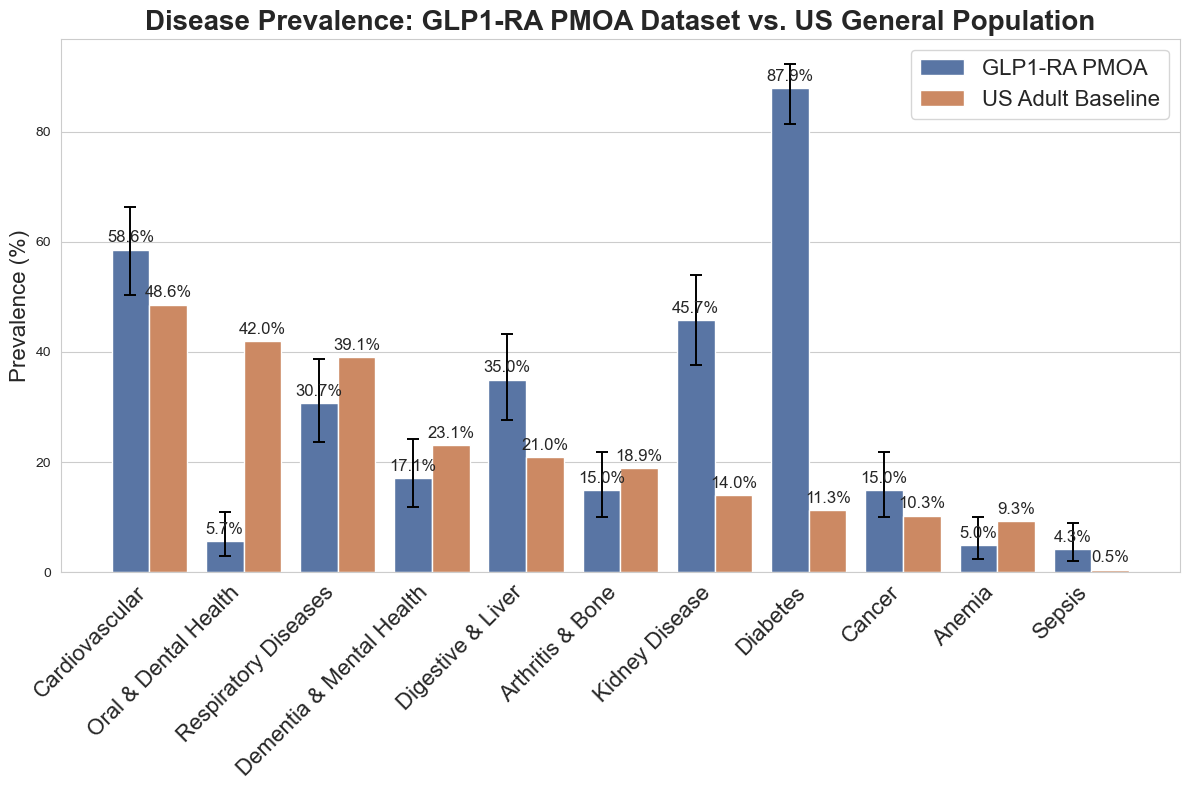

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
# data = pd.read_pickle('full_linked_diagnosis_data.pkl')

# 2. Extract ALL unique canonical names
all_unique_names = set()
for pmc_id, diagnoses in data.items():
    for raw_diag, candidates in diagnoses.items():
        if candidates:
            for cand in candidates:
                all_unique_names.add(cand['name'])

# 3. New Group Mapping Logic
def assign_disease_groups(name):
    name_lower = name.lower()
    groups = []
    
    # --- 1. Anemia (Expanded) ---
    if any(x in name_lower for x in [
        'anemia', 'anaemia', 'hemoglobin', 'haemoglobin', 'iron deficiency', 'iron', 
        'ferritin', 'thalassemia', 'sickle cell', 'sideroblastic', 'spherocytosis', 
        'pernicious', 'aplastic', 'hemolytic', 'cytopenia', 'pancytopenia', 
        'myelodysplastic', 'low rbc', 'erythroblastopenia'
    ]):
        groups.append('Anemia')

    # --- 2. Arthritis and Bone (Expanded) ---
    if any(x in name_lower for x in [
        'arthritis', 'osteoarth', 'rheumatoid', 'gout', 'ankylosing', 'spondylitis', 
        'spondylosis', 'spondyloarthropathy', 'degenerative joint', 'arthropathy',
        'osteoporosis', 'osteopenia', 'bone density', 'fracture', 'bone loss', 'bone disease',
        'fibromyalgia', 'lupus', 'sle', 'connective tissue disease', 'polymyalgia',
        'scoliosis', 'kyphosis', 'lordosis', 'osteomyelitis', 'paget', 'rickets', 
        'osteomalacia', 'avascular necrosis', 'synovitis', 'bursitis', 'tendonitis'
    ]):
        groups.append('Arthritis & Bone')

    # --- 3. Cancer (Expanded) ---
    if any(x in name_lower for x in [
        'cancer', 'neoplasm', 'tumor', 'tumour', 'malignan', 'carcinoma', 'sarcoma', 
        'lymphoma', 'leukemia', 'leukaemia', 'myeloma', 'metastasis', 'metastatic', 
        'glioma', 'blastoma', 'melanoma', 'adenoca', 'plasmacytoma', 'cystadenoma', 
        'neurofibroma', 'oncolog', 'chemotherapy', 'radiation therapy', 'hodgkin', 
        'wilms', 'kaposi', 'seminoma', 'teratoma', 'mesothelioma', 'myeloproliferative'
    ]):
        groups.append('Cancer')

    # --- 4. Cardiovascular (Expanded) ---
    stroke_terms = [
        'stroke', 'cerebrovascular', 'cva', 'brain attack', 'transient ischemic', 'tia', 
        'hemorrhage', 'intracranial', 'cerebral aneurysm', 'subarachnoid', 'infarct'
    ]
    cholesterol_terms = [
        'lipid', 'cholesterol', 'hypercholes', 'dyslipidemia', 'triglyceride', 'lipoprotein', 
        'hyperlipidemia'
    ]
    heart_terms = [
        'coronary', 'heart disease', 'myocardial', 'heart failure', 'chf', 'atrial fib', 
        'afib', 'infarction', 'angina', 'ischemic', 'ischemia', 'valve', 'arrhythmia', 
        'ventricular', 'cardiomyopathy', 'tachycardia', 'bradycardia', 'fibrillation', 
        'stenosis', 'regurgitation', 'pericarditis', 'endocarditis', 'aneurysm', 
        'cardiovascular', 'cardiac', 'aortic', 'mitral', 'tricuspid', 'vascular', 
        'peripheral artery', 'pad', 'arteriosclerosis', 'atherosclerosis', 'thrombosis', 
        'embolism', 'dvt', 'phlebitis', 'claudication', 'hypertension', 'hypertensive', 
        'high blood pressure', 'pre-eclampsia', 'eclampsia', 'hellp syndrome', 'hypotension', 
        'shock', 'wolff-parkinson-white', 'qt interval'
    ]
    if any(x in name_lower for x in stroke_terms + cholesterol_terms + heart_terms):
        groups.append('Cardiovascular')

    # --- 5. Dementia and Mental Health (Expanded) ---
    if any(x in name_lower for x in [
        'dementia', 'alzheimer', 'cognitive', 'delirium', 'amnesia', 'memory loss',
        'adhd', 'attention deficit', 'hyperactivity', 'autism', 'asperger', 
        'depression', 'depress', 'mood disorder', 'dysthymia', 'bipolar', 'mania', 
        'suicid', 'psychosis', 'psychotic', 'schizo', 'hallucination', 'delusion',
        'affective disorder', 'anhedonia', 'anxiety', 'panic', 'phobia', 'stress', 
        'obsess', 'compuls', 'ocd', 'ptsd', 'trauma', 'adjustment disorder',
        'mental', 'psychiatric', 'behavioral', 'emotional', 'insomnia', 
        'eating disorder', 'anorexia', 'bulimia', 'substance', 'dependence', 
        'alcoholism', 'withdrawal', 'intoxication', 'personality disorder'
    ]):
        groups.append('Dementia & Mental Health')

    # --- 6. Diabetes (Expanded) ---
    if any(x in name_lower for x in [
        'diabetes', 'diabetic', 'dm', 'type 1', 'type 2', 'insulin', 'metabolic syndrome', 
        'glucose', 'hyperglycem', 'hypoglycem', 'ketoacidosis', 'hba1c', 'glycosylated', 
        'neuropathy', 'retinopathy', 'nephropathy', 'polyuria', 'polydipsia'
    ]):
        groups.append('Diabetes')

    # --- 7. Digestive and Liver (Expanded) ---
    liver_terms = [
        'liver', 'hepatic', 'cirrhosis', 'hepatitis', 'steato', 'fatty liver', 'nafld', 'nash', 
        'ascites', 'varices', 'jaundice', 'bilirubin', 'bile', 'biliary', 'cholangitis', 
        'gallbladder', 'cholecyst', 'cholelithiasis', 'gallstone'
    ]
    digestive_terms = [
        'digestive', 'gastro', 'stomach', 'bowel', 'intestin', 'colon', 'colorectal', 
        'esophag', 'pancrea', 'ulcer', 'peptic', 'gerd', 'reflux', 'heartburn', 
        'ibd', 'crohn', 'colitis', 'diverticul', 'constipation', 'diarrhea', 'dysphagia',
        'hernia', 'hiatal', 'inguinal', 'umbilical', 'periton', 'celiac', 'malabsorption', 
        'gastritis', 'duodenitis', 'ileitis', 'proctitis', 'rectal', 'anal', 'fissure', 
        'hemorrhoid', 'ibs', 'irritable bowel', 'dyspepsia'
    ]
    if any(x in name_lower for x in liver_terms + digestive_terms):
        groups.append('Digestive & Liver')

    # --- 8. Kidney Disease (Expanded) ---
    if any(x in name_lower for x in [
        'kidney', 'renal', 'nephr', 'ckd', 'esrd', 'glomerul', 'azotemia', 'albuminuria', 
        'proteinuria', 'creatinine', 'dialysis', 'hemodialysis', 'peritoneal', 
        'calculus', 'stone', 'lithiasis', 'pyelonephritis', 'hydronephrosis', 
        'uremia', 'uremic', 'kidney failure', 'renal failure'
    ]):
        groups.append('Kidney Disease')

    # --- 9. Oral and Dental Health (Expanded) ---
    if any(x in name_lower for x in [
        'dental', 'tooth', 'teeth', 'gum', 'periodont', 'gingiv', 'oral', 'mouth', 
        'caries', 'cavity', 'stomatitis', 'mucositis', 'abscess', 'pulpitis', 
        'alveol', 'edentulism', 'denture', 'malocclusion', 'temporomandibular', 'tmj'
    ]):
        groups.append('Oral & Dental Health')

    # --- 10. Respiratory Diseases (Expanded) ---
    if any(x in name_lower for x in [
        'asthma', 'copd', 'obstructive pulmonary', 'emphysema', 'bronchitis', 'bronchiectasis', 
        'airway', 'allergy', 'allergic', 'hay fever', 'rhinitis', 'sinusitis', 'nasal polyp', 
        'pneumoconiosis', 'asbestosis', 'silicosis', 'lung', 'pulmonary', 'respiratory', 
        'pleura', 'pleurisy', 'pleuritis', 'effusion', 'pneumothorax', 'atelectasis', 
        'tuberculosis', 'tb', 'sarcoidosis', 'cystic fibrosis', 'bronchiolitis', 
        'pneumonia', 'pneumonitis', 'covid', 'sars', 'mers', 'influenza', 'flu', 
        'ards', 'respiratory failure', 'respiratory distress', 'hypox', 'dyspnea', 
        'shortness of breath', 'sputum', 'cough', 'apnea', 'sleep apnea', 'hypercapnia'
    ]):
        groups.append('Respiratory Diseases')

    # --- 11. Sepsis (NEW: Auto-Detection) ---
    if any(x in name_lower for x in [
        'sepsis', 'septic', 'septicemia', 'bacteremia', 'fungemia', 'viremia', 
        'sirs', 'systemic inflammatory', 'shock', 'toxic shock', 'urosepsis'
    ]):
        groups.append('Sepsis')

    return groups

# 4. Generate Map
umls_to_group_map = {name: assign_disease_groups(name) for name in all_unique_names}

# 5. Calculate Prevalence
patient_groups_list = []
for pmc_id, diagnoses in data.items():
    patient_buckets = set()
    for raw_diag, candidates in diagnoses.items():
        if not candidates:
            continue
        for cand in candidates:
            groups = umls_to_group_map.get(cand['name'], [])
            patient_buckets.update(groups)
    patient_groups_list.append(list(patient_buckets))

# 6. Aggregate Stats
total_patients = len(data)
all_groups_flat = [g for sublist in patient_groups_list for g in sublist]
group_counts = pd.Series(all_groups_flat).value_counts()
dataset_prevalence = (group_counts / total_patients) * 100

# 7. Define US Reference Data
us_prevalence_sources = {
    'Cardiovascular': 48.6,
    'Oral & Dental Health': 42.0,
    'Respiratory Diseases': 39.1,
    'Dementia & Mental Health': 23.1,
    'Digestive & Liver': 21.0,
    'Arthritis & Bone': 18.9,
    'Kidney Disease': 14.0,
    'Diabetes': 11.3,
    'Cancer': 10.3,
    'Anemia': 9.3,
    'Sepsis': 0.5
}

# 8. Create Final DataFrame
comparison_df = pd.DataFrame({
    'Condition': us_prevalence_sources.keys(),
    'US_Pop_Rate': us_prevalence_sources.values()
})

comparison_df['Dataset_Rate'] = comparison_df['Condition'].map(dataset_prevalence).fillna(0)

# ---------------------------
# NEW: Wilson CI for Dataset_Rate
# ---------------------------
def wilson_ci(k, n, z=1.96):
    """Wilson score interval for a binomial proportion."""
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1 + (z**2)/n
    center = (p + (z**2)/(2*n)) / denom
    half = (z * np.sqrt((p*(1-p) + (z**2)/(4*n)) / n)) / denom
    return center - half, center + half

ci_low = []
ci_high = []
for cond in comparison_df["Condition"]:
    k = int(group_counts.get(cond, 0))
    lo, hi = wilson_ci(k, total_patients)
    ci_low.append(lo * 100)
    ci_high.append(hi * 100)

comparison_df["Dataset_CI_low"] = ci_low
comparison_df["Dataset_CI_high"] = ci_high
comparison_df["Dataset_err_low"] = comparison_df["Dataset_Rate"] - comparison_df["Dataset_CI_low"]
comparison_df["Dataset_err_high"] = comparison_df["Dataset_CI_high"] - comparison_df["Dataset_Rate"]

print("Prevalence Comparison Table:")
display(comparison_df.round(2))

# 9. Plot
plt.figure(figsize=(12, 8))
plot_data = comparison_df.melt(
    id_vars='Condition',
    value_vars=['Dataset_Rate', 'US_Pop_Rate'],
    var_name='Source',
    value_name='Prevalence (%)'
)

plot_data['Source'] = plot_data['Source'].replace({
    'Dataset_Rate': 'GLP1-RA PMOA',
    'US_Pop_Rate': 'US Adult Baseline'
})

sns.set_style("whitegrid")
ax = sns.barplot(
    data=plot_data,
    x='Condition',
    y='Prevalence (%)',
    hue='Source',
    palette=['#4c72b0', '#dd8452']
)

# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=12)

# ---------------------------
# NEW: Add error bars for GLP1-RA PMOA bars only
# ---------------------------
# With your palette order, the first container corresponds to 'GLP1-RA PMOA'
glp_container = ax.containers[0]

# Ensure the order aligns with comparison_df['Condition']
# (This is true as long as you do not reorder/sort categories elsewhere.)
for i, bar in enumerate(glp_container):
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height()

    err_low = float(comparison_df.iloc[i]["Dataset_err_low"])
    err_high = float(comparison_df.iloc[i]["Dataset_err_high"])

    ax.errorbar(
        x, y,
        yerr=np.array([[err_low], [err_high]]),
        fmt="none",
        ecolor="black",      # <-- high-contrast error bars
        elinewidth=1.4,      # <-- thicker line
        capsize=4,
        capthick=1.4         # <-- thicker caps
    )
plt.title('Disease Prevalence: GLP1-RA PMOA Dataset vs. US General Population', fontsize=20, fontweight='bold')
plt.ylabel('Prevalence (%)', fontsize=16)
plt.xlabel('')
plt.xticks(rotation=45, ha='right', fontsize=16)
plt.legend(title=None, fontsize=16)
plt.tight_layout()

# plt.show()
plt.savefig('/Users/kumars33/Desktop/Diabetes_LLM_annotation/GLP_AMIA/paper_plots/disease_prevalence.pdf', dpi=300, bbox_inches='tight')